# Lab 2 - Optimization

In [233]:
# Google Colab
import os
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/tomaztc/Tomav2.git"
    REPO_DIR = "/content/Tomav2/"

    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}

    os.chdir(REPO_DIR)

In [234]:
# Imports
from importlib.util import find_spec
if find_spec("matplotlib") is None or find_spec("scipy") is None or find_spec("numpy") is None \
    or find_spec("pandas") is None or find_spec("seaborn") is None or find_spec("pymoo") is None:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "scipy", "numpy", "pandas", "seaborn", "pymoo"])

import warnings
import json 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pymoo
import time

from designTool.constants import gravity
from designTool.analyze import analyze
from designTool.geometry import geometry
from designTool.standard_airplane import standard_airplane
from designTool.plots import plot_geometry
from designTool.auxiliary import atmosphere
from designTool.aerodynamics import aerodynamics

# Config
np.random.seed(1234)
pd.options.display.float_format = "{:,.2f}".format
warnings.simplefilter("error")
sns.set_theme(style="whitegrid", context="notebook")

# Constantes
TOMAV_KWARGS = ["delta_xr_w", "x_tank_c_w"]
CONDICAO_SEGUNDO_SEGMENTO = {
    "Mach": 0.30,
    "altitude": 0,
    "n_engines_failed": 1,
    "highlift_config": "takeoff",
    "lg_down": 1,
    "h_ground": 10.668,
}

In [ ]:
# Funções
def aerodynamics_condicao_e_CL(airplane: dict, condicao: dict, CL: float) -> tuple[float, float, dict]:
    CD, CLmax, dragDict = aerodynamics(airplane, condicao["Mach"], condicao["altitude"], CL,
                                       n_engines_failed=condicao["n_engines_failed"],
                                       highlift_config=condicao["highlift_config"], lg_down=condicao["lg_down"],
                                       h_ground=condicao["h_ground"])
    return CD, CLmax, dragDict

def criar_airplane_parametros(airplane_name: str, parametros: dict) -> dict:
    airplane = standard_airplane(airplane_name, **{parametro: valor for parametro, valor in parametros.items() if airplane_name=="Tomav" and parametro in TOMAV_KWARGS})

    for parametro, valor in parametros.items():
        if airplane_name=="Tomav" and parametro in TOMAV_KWARGS:
            pass
        airplane["inputs"][parametro] = valor

    return airplane

def calcular_dados_otimizacao(airplane_name: str, x_norm: np.ndarray, lb: np.ndarray, ub: np.ndarray, nomes_parametros: list) -> dict | None:
    key = tuple(np.round(x_norm, 11))
    if key in cache:
        return cache[key]
    
    x = desnormalizar(x_norm, lb, ub)
    parametros = {parametro: valor for parametro, valor in zip(nomes_parametros, x)}
    airplane = criar_airplane_parametros(airplane_name, parametros)

    try:
        analyze(airplane)
    except:
        return None

    W0 = airplane["thrust_matching"]["W0"]
    Wf = airplane["thrust_matching"]["W_fuel"]
    T0 = airplane["thrust_matching"]["T0"]
    sigma = atmosphere(airplane["inputs"]["altitude_takeoff"], airplane["inputs"]["deltaISA_takeoff"])["density"] / 1.225
    _, CLmax_TO, _ = aerodynamics_condicao_e_CL(airplane, CONDICAO_SEGUNDO_SEGMENTO, 0)
    d_TO = 0.2387 / (sigma * CLmax_TO * airplane["inputs"]["S_w"]) * W0**2 / T0

    dados = {
        # Saídas
        "W0": W0,
        "Wf": Wf,
        # Restrições
        "deltaS_wlan": airplane["thrust_matching"]["deltaS_wlan"], # 1
        "SM_fwd": airplane["balance"]["SM_fwd"], # 2
        "SM_aft": airplane["balance"]["SM_aft"], # 3
        "frac_nlg_aft": airplane["landing_gear"]["frac_nlg_aft"], # 4
        "frac_nlg_fwd": airplane["landing_gear"]["frac_nlg_fwd"], # 5
        "alpha_tipback": airplane["landing_gear"]["alpha_tipback"], # 6
        "alpha_tailstrike": airplane["landing_gear"]["alpha_tailstrike"], # 7
        "phi_overturn": airplane["landing_gear"]["phi_overturn"], # 8
        # Restrição 9 já está definida no input b_tank_b_w = 0.95
        "b_w": airplane["geometry"]["b_w"], # 10
        # Restrição 11 já está definida no input y_mlg = 5.5
        "tail_height": airplane["geometry"]["zt_v"] - airplane["inputs"]["z_lg"], # 12
        # Restrições adicionais:
        "CLv": airplane["balance"]["CLv"], # 13
        "tank_excess": airplane["balance"]["tank_excess"], # 14
        "mlg_xcg_margin": airplane["inputs"]["x_mlg"] - airplane["balance"]["xcg_aft"], # 15
        "d_TO": d_TO, # 16
    }
    cache[key] = dados
    return dados

def normalizar(x: np.ndarray, lb: np.ndarray, ub: np.ndarray) -> np.ndarray:
    return (x - lb) / (ub - lb)

def desnormalizar(x_norm: np.ndarray, lb: np.ndarray, ub: np.ndarray) -> np.ndarray:
    x = lb + x_norm * (ub - lb)
    return np.clip(x, lb, ub)

def funcao_objetivo(airplane_name: str, x_norm: np.ndarray, lb: np.ndarray, ub: np.ndarray, nomes_parametros: list, W0_inicial: float) -> float:
    dados = calcular_dados_otimizacao(airplane_name, x_norm, lb, ub, nomes_parametros)
    x = desnormalizar(x_norm, lb, ub)
    parametros_hist.append(x)
    W0_hist.append(dados["W0"] if dados is not None else np.nan)
    if dados is None:
        return 1e10
    else:
        return dados["W0"] / W0_inicial

def confun(x_norm: np.ndarray, airplane_name: str, lb: np.ndarray, ub: np.ndarray, nomes_parametros: list, restricoes_limites: dict) -> np.ndarray:
    # ATTENTION: It is really important to normalize input variables and constraints. For example, the aft static margin constraint can be defined as: (SM_aft/0.05 −1) ≥ 0.
    dados = calcular_dados_otimizacao(airplane_name, x_norm, lb, ub, nomes_parametros)
    g = []
    restricoes_list = []
    for nome_restricao, (limite_inferior, limite_superior) in restricoes_limites.items():
        if limite_inferior is not None:
            if dados is None:
                g_i = -1000
                restricoes_list.append(np.nan)
            else:
                if limite_inferior == 0:
                    g_i = dados[nome_restricao]
                else:
                    g_i = (dados[nome_restricao] - limite_inferior) / abs(limite_inferior)
                restricoes_list.append(dados[nome_restricao])
            g.append(g_i)
        if limite_superior is not None:
            if dados is None:
                g_i = -1000
                restricoes_list.append(np.nan)
            else:
                if limite_superior == 0:
                    g_i = -dados[nome_restricao]
                else:
                    g_i = (limite_superior - dados[nome_restricao]) / abs(limite_superior)
                restricoes_list.append(dados[nome_restricao])
            g.append(g_i)

    restricoes_hist.append(restricoes_list)        
    return np.array(g)

def otimizar_aviao(airplane_name: str, parametros_limites: dict, parametros_iniciais: np.ndarray, restricoes_limites: dict) -> tuple:
    lb = np.array([limite[0] for limite in parametros_limites.values()])
    ub = np.array([limite[1] for limite in parametros_limites.values()])
    nomes_parametros = list(parametros_limites.keys())
    x_norm_inicial = normalizar(parametros_iniciais, lb, ub)
    dados_inicial = calcular_dados_otimizacao(airplane_name, x_norm_inicial, lb, ub, nomes_parametros)
    if dados_inicial is None:
        raise ValueError
    W0_inicial = dados_inicial["W0"]
    start = time.perf_counter()
    result = scipy.optimize.minimize(
        fun=lambda x_norm: funcao_objetivo(airplane_name, x_norm, lb, ub, nomes_parametros, W0_inicial),
        x0=normalizar(parametros_iniciais, lb, ub),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * len(parametros_limites),
        constraints=[{
            'type': 'ineq',
            'fun': lambda x_norm: confun(x_norm, airplane_name, lb, ub, nomes_parametros, restricoes_limites)
        }],
        options={"ftol": 1e-7, "disp": True, "maxiter": 500, "eps": 1e-3}, 
    )
    elapsed = time.perf_counter() - start

    dados_opt = calcular_dados_otimizacao(airplane_name, result.x, lb, ub, nomes_parametros)
    if dados_opt is None:
        raise ValueError
    x = desnormalizar(result.x, lb, ub)
    parametros = {parametro: valor for parametro, valor in zip(nomes_parametros, x)}
    airplane_opt = criar_airplane_parametros(airplane_name, parametros)
    analyze(airplane_opt)
    return result, elapsed, parametros, airplane_opt, dados_inicial, dados_opt

def tabela_latex(df: pd.DataFrame, unidades: list | None) -> str:
    if unidades is None:
        unidades = [""] * len(df.columns)
        
    def esc(s):
        return s.replace("_", r"\_")

    if any("point" in col for col in df.columns):
        lines = [
            r"\begin{tabular}{l|" + "c" * len(df.columns) + "}",
            " & " + " & ".join(df.columns) +
            r" \\",
            r"\hline",
        ]
    else:
        lines = [
            r"\begin{tabular}{l|" + "c" * len(df.columns) + "}",
            " & " + " & ".join(f"${col}$" for col in df.columns) +
            r" \\",
            r"\hline",
        ]

    for index, row in df.iterrows():
        values = ["$" + f"{value:.2f}" +  rf"\,{unidade}$" if pd.notna(value) else r"$\cdots$" for value, unidade in zip(row, unidades)]
        lines.append(f"{index} & " + " & ".join(values) + r" \\")

    lines.append(r"\end{tabular}")
    return "\n".join(lines)

def mudar_escala(df: pd.DataFrame) -> None:
    linhas_angulo = df.index.str.contains(r"alpha|phi|sweep", case=False, regex=True)
    linhas_porcentagem = df.index.str.contains(r"frac|excess|_c_w|_b_w|SM_", case=False, regex=True)
    linhas_peso = df.index.str.contains(r"MTOW", case=False, regex=True)
    df.loc[linhas_angulo, :] = np.rad2deg(df.loc[linhas_angulo, :])
    df.loc[linhas_porcentagem, :] = df.loc[linhas_porcentagem, :]*100
    df.loc[linhas_peso, :] = df.loc[linhas_peso, :]/gravity

# 2) Default Aircraft Optimization
Minimizar W0(x)

w.r.t. x = [AR_w, S_w]

x0 = [7.5, 90]

Restrições:

[7, 80] <= [AR_w, S_w] <= [12, 120]

b_w(x) - 30 <= 0

In [236]:
airplane_name = "fokker100"
fokker100_inicial = criar_airplane_parametros(airplane_name, {"AR_w": 9, "S_w": 100})
analyze(fokker100_inicial)

parametros_iniciais = np.array([9, 100])

parametros_limites = {
    "AR_w": [7, 12],
    "S_w": [80, 120]
}


restricoes_limites = {
    "b_w": [None, 30]
}

parametros_hist = []
W0_hist = []
restricoes_hist = []
cache = {}
result, elapsed, parametros, fokker100_opt, dados_fokker100_inicial, dados_fokker100_opt = otimizar_aviao(airplane_name, parametros_limites, parametros_iniciais, restricoes_limites)

print(result)
print(parametros)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.9801997755018144
            Iterations: 10
            Function evaluations: 30
            Gradient evaluations: 10
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.9801997755018144
           x: [ 7.132e-01  1.281e-01]
         nit: 10
         jac: [ 4.257e-05  5.947e-05]
        nfev: 30
        njev: 10
 multipliers: [ 0.000e+00]
{'AR_w': 10.56579605694905, 'S_w': 85.12328180316854}


## 1. Fill the following table with the optimization results:

In [237]:
tabela = []
for airplane in (fokker100_inicial, fokker100_opt):
    AR_w = airplane["inputs"]["AR_w"]
    S_w = airplane["inputs"]["S_w"]
    MTOW = airplane["thrust_matching"]["W0"] / gravity
    b_w = airplane["geometry"]["b_w"]
    tabela.append([AR_w, S_w, MTOW, b_w])
df = pd.DataFrame(
    tabela,
    index=["Starting point", "Optimized point"],
    columns=["AR_w", "S_w", "MTOW", "b_w"]
)
print(df)

                 AR_w    S_w      MTOW   b_w
Starting point   9.00 100.00 42,675.09 30.00
Optimized point 10.57  85.12 41,830.12 29.99


LaTeX:

In [238]:
unidades = ["", r"\text{m}^2", r"\text{kgf}", r"\text{m}"]
latex = tabela_latex(df, unidades)
print(latex)

\begin{tabular}{l|cccc}
 & $AR_w$ & $S_w$ & $MTOW$ & $b_w$ \\
\hline
Starting point & $9.00\,$ & $100.00\,\text{m}^2$ & $42675.09\,\text{kgf}$ & $30.00\,\text{m}$ \\
Optimized point & $10.57\,$ & $85.12\,\text{m}^2$ & $41830.12\,\text{kgf}$ & $29.99\,\text{m}$ \\
\end{tabular}


## 2. What is the relative improvement of the objective function, in percentage, after the optimization?

In [239]:
W0_inicial = fokker100_inicial["thrust_matching"]["W0"]
W0_opt = fokker100_opt["thrust_matching"]["W0"]
print(f"MTOW inicial: {W0_inicial/gravity:.2f} kgf")
print(f"MTOW otimizado: {W0_opt/gravity:.2f} kgf")
print(f"Redução: {(W0_inicial - W0_opt)/gravity:.2f} kgf ({(W0_inicial - W0_opt)/W0_inicial*100:.2f}%)")

MTOW inicial: 42675.09 kgf
MTOW otimizado: 41830.12 kgf
Redução: 844.98 kgf (1.98%)


## 3. How many function calls were needed in this optimization?

In [240]:
print(f"{result.nfev} chamadas")

30 chamadas


## 4. Is the optimum constrained? What are the active constraints?
Não, pois b_w < 30

# 3) Team Aircraft Optimization

In [241]:
airplane_name = "Tomav"
tomav_inicial = standard_airplane(airplane_name)
analyze(tomav_inicial)

parametros_limites = { # parâmetro: (mínimo, máximo)
    "delta_xr_w": (-15, 0),
    "S_w": (250, 400),
    "sweep_w": (np.deg2rad(25), np.deg2rad(45)),
    "AR_w": (6, 10.5),
    "taper_w": (0.17, 1),
    "c_flap_c_wing": (0.15, 0.33),
    "b_flap_b_wing": (0.40, 0.65),
    "x_tank_c_w": (0.1, 0.7),
}

nomes_parametros = list(parametros_limites.keys())
parametros_iniciais = np.array([tomav_inicial["inputs"][parametro] for parametro in parametros_limites])

restricoes_limites = { # restrição: (mínimo, máximo), None para ignorar
  "deltaS_wlan": (0, None), # 1
  "SM_fwd": (None, 0.30), # 2
  "SM_aft": (0.05, None), # 3
  "frac_nlg_aft": (0.03, None), # 4
  "frac_nlg_fwd": (None, 0.18), # 5
  "alpha_tipback": (np.deg2rad(15), None), # 6
  "alpha_tailstrike": (np.deg2rad(10), None), # 7
  "phi_overturn": (None, np.deg2rad(63)), # 8
  # Restrição 9 já está definida no input b_tank_b_w = 0.95
  "b_w": (52, 62), # 10
  # Restrição 11 já está definida no input y_mlg = 5.5
  "tail_height": (None, 20), # 12
  # Restrições adicionais:
  "CLv": (None, 0.75), # 13
  "tank_excess": (0, None), # 14
  "mlg_xcg_margin": (0, None), # 15
  "d_TO": (None, 2900) # 16
}

parametros_hist = []
W0_hist = []
restricoes_hist = []
cache = {}
result, elapsed, parametros, tomav_opt, dados_tomav_inicial, dados_tomav_opt = otimizar_aviao(airplane_name, parametros_limites, parametros_iniciais, restricoes_limites)

print(result)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.9766547336007276
            Iterations: 10
            Function evaluations: 90
            Gradient evaluations: 10
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.9766547336007276
           x: [ 6.559e-01  2.412e-01  4.818e-01  1.000e+00  1.497e-17
                1.000e+00  9.256e-01  3.664e-02]
         nit: 10
         jac: [ 5.637e-02  5.812e-02 -4.690e-02 -3.904e-02  5.030e-02
                1.229e-02  7.367e-03  0.000e+00]
        nfev: 90
        njev: 10
 multipliers: [ 0.000e+00  1.483e-02 ...  0.000e+00  1.299e-01]


## 1. Give the optimization problem definition and reasons behind the selection of design variables.
Minimizar W0(x)

w.r.t. x = 6 variáveis:
1. delta_xr_w (explicar que essa variável que eu inventei altera o x da asa, rodas e motores junto)
2.
3.
4.
5.
6.


x0 = avião final PRJ-22

Restrições:

1. Landing requirement: deltaS_wlan ≥ 0
2. Static stability: SM_fwd ≤ 0.30
3. Static stability: SM_aft ≥ 0.05
4. Nose landing gear weight fraction: frac_nlg_fwd ≤ 0.18
5. Nose landing gear weight fraction: frac_nlg_aft ≥ 0.03
6. Main landing gear position: alpha_tipback ≥ 15 deg
7. Main landing gear position: alpha_tailstrike ≥ 10 deg
8. Main landing gear position: phi_overturn ≤ 63 deg
9. Fuel tank volume: b_tank_b_w ≤ 0.95 (já está definido b_tank_b_w = 0.95)
10. Wingspan limit for ICAO gate constraint: see Tab. 1
  - Wingspan = b_w = 58.86425061104575m -> Code E -> 52m < b_w < 65m
11. Wheel span limit for ICAO gate constraint: see Tab. 1
  - Code E => 9 < 2*y_mlg < 14
  - 9 < 2*5.5 < 14 => OK (não entra como restrição)
12. Heihgt limit for FAA Airplane Design Group: see Tab. 2
- Wingspan = 58.86425061104575m => ADG V
- Tail Height = zt_v - z_lg = 12.507446283245763m - (-5.585m) = 18,09244628m => ADG IV
- Pior: ADG V => Tail Height = zt_v - z_lg < 20m

## 2. Explain if new constraints or objectives were added.
Restrições adicionais:
1.  CLv <= 0.75 (controle lateral)
2.  tank_excess >= 0 (combustível suficiente)
3.  x_mlg >= x_cg_aft (não tombar)
4.  d_TO < 2900 (decolar)

## 3. Generate a table comparing values of design variables, constraints, and objective of the initial and the optimized configurations.

Parâmetros e objetivo:

In [242]:
tabela = {titulo: {parametro: airplane["inputs"][parametro] for parametro in nomes_parametros} for titulo, airplane in zip(["Starting point", "Optimized point"], (tomav_inicial, tomav_opt))}
tabela["Starting point"]["MTOW"] = dados_tomav_inicial["W0"]
tabela["Optimized point"]["MTOW"] = dados_tomav_opt["W0"]
limites = {"Mínimo": {parametro: limite[0] for parametro, limite in parametros_limites.items()},
           "Máximo": {parametro: limite[1] for parametro, limite in parametros_limites.items()}}
limites["Mínimo"]["MTOW"] = None
limites["Máximo"]["MTOW"] = None
df = pd.DataFrame({**tabela, **limites})

linhas_angulo = df.index.str.contains(r"alpha|phi|sweep", case=False, regex=True)
linhas_porcentagem = df.index.str.contains(r"frac|excess|_c_w|_b_w|SM_", case=False, regex=True)
linhas_peso = df.index.str.contains(r"MTOW", case=False, regex=True)
df.loc[linhas_angulo, :] = np.rad2deg(df.loc[linhas_angulo, :])
df.loc[linhas_porcentagem, :] = df.loc[linhas_porcentagem, :]*100
df.loc[linhas_peso, :] = df.loc[linhas_peso, :]/gravity
print(df)


               Starting point  Optimized point  Mínimo  Máximo
delta_xr_w              -5.10            -5.16  -15.00    0.00
S_w                    330.00           286.18  250.00  400.00
sweep_w                 35.05            34.64   25.00   45.00
AR_w                    10.50            10.50    6.00   10.50
taper_w                  0.17             0.17    0.17    1.00
c_flap_c_wing           33.00            33.00   15.00   33.00
b_flap_b_wing           65.00            63.14   40.00   65.00
x_tank_c_w              14.00            12.20   10.00   70.00
MTOW               253,650.42       247,728.89     NaN     NaN


LaTeX

In [243]:
unidades = [r"\text{m}", r"\text{m}^2", r"^\circ", "", "", "", "", "", r"\text{kgf}"]
latex = tabela_latex(df, unidades)
print(latex)

\begin{tabular}{l|cccc}
 & $Starting point$ & $Optimized point$ & $Mínimo$ & $Máximo$ \\
\hline
delta_xr_w & $-5.10\,\text{m}$ & $-5.16\,\text{m}^2$ & $-15.00\,^\circ$ & $0.00\,$ \\
S_w & $330.00\,\text{m}$ & $286.18\,\text{m}^2$ & $250.00\,^\circ$ & $400.00\,$ \\
sweep_w & $35.05\,\text{m}$ & $34.64\,\text{m}^2$ & $25.00\,^\circ$ & $45.00\,$ \\
AR_w & $10.50\,\text{m}$ & $10.50\,\text{m}^2$ & $6.00\,^\circ$ & $10.50\,$ \\
taper_w & $0.17\,\text{m}$ & $0.17\,\text{m}^2$ & $0.17\,^\circ$ & $1.00\,$ \\
c_flap_c_wing & $33.00\,\text{m}$ & $33.00\,\text{m}^2$ & $15.00\,^\circ$ & $33.00\,$ \\
b_flap_b_wing & $65.00\,\text{m}$ & $63.14\,\text{m}^2$ & $40.00\,^\circ$ & $65.00\,$ \\
x_tank_c_w & $14.00\,\text{m}$ & $12.20\,\text{m}^2$ & $10.00\,^\circ$ & $70.00\,$ \\
MTOW & $253650.42\,\text{m}$ & $247728.89\,\text{m}^2$ & $\cdots$ & $\cdots$ \\
\end{tabular}


Restrições:

In [ ]:
tabela = {titulo: {restricao: dados[restricao] for restricao in restricoes_limites}for titulo, dados in zip(["Starting point", "Optimized point"], (dados_tomav_inicial, dados_tomav_opt))}

limites = {"Mínimo": {restricao: limite[0] for restricao, limite in restricoes_limites.items()},
           "Máximo": {restricao: limite[1] for restricao, limite in restricoes_limites.items()}}
df = pd.DataFrame({**tabela, **limites})
mudar_escala(df)
print(df)

                  Starting point  Optimized point  Mínimo   Máximo
deltaS_wlan               155.65           113.44    0.00      NaN
SM_fwd                     36.16            30.00     NaN    30.00
SM_aft                     19.81             8.17    5.00      NaN
frac_nlg_aft                5.43             6.65    3.00      NaN
frac_nlg_fwd               10.17            12.56     NaN    18.00
alpha_tipback              12.37            15.00   15.00      NaN
alpha_tailstrike           10.63            10.59   10.00      NaN
phi_overturn               49.32            50.09     NaN    63.00
b_w                        58.86            54.82   52.00    62.00
tail_height                18.09            17.42     NaN    20.00
CLv                         0.69             0.75     NaN     0.75
tank_excess                19.17            -0.00    0.00      NaN
mlg_xcg_margin              1.23             1.50    0.00      NaN
d_TO                    2,606.38         2,900.00     NaN 2,90

LaTeX

In [245]:
unidades = [r"\text{m}^2", r"\%", r"\%", r"\%", r"\%", r"^\circ", r"^\circ", r"^\circ", r"\text{m}", r"\text{m}", "", r"\%", r"\text{m}", r"\text{m}"]
latex = tabela_latex(df, unidades)
print(latex)

\begin{tabular}{l|cccc}
 & $Starting point$ & $Optimized point$ & $Mínimo$ & $Máximo$ \\
\hline
deltaS_wlan & $155.65\,\text{m}^2$ & $113.44\,\%$ & $0.00\,\%$ & $\cdots$ \\
SM_fwd & $36.16\,\text{m}^2$ & $30.00\,\%$ & $\cdots$ & $30.00\,\%$ \\
SM_aft & $19.81\,\text{m}^2$ & $8.17\,\%$ & $5.00\,\%$ & $\cdots$ \\
frac_nlg_aft & $5.43\,\text{m}^2$ & $6.65\,\%$ & $3.00\,\%$ & $\cdots$ \\
frac_nlg_fwd & $10.17\,\text{m}^2$ & $12.56\,\%$ & $\cdots$ & $18.00\,\%$ \\
alpha_tipback & $12.37\,\text{m}^2$ & $15.00\,\%$ & $15.00\,\%$ & $\cdots$ \\
alpha_tailstrike & $10.63\,\text{m}^2$ & $10.59\,\%$ & $10.00\,\%$ & $\cdots$ \\
phi_overturn & $49.32\,\text{m}^2$ & $50.09\,\%$ & $\cdots$ & $63.00\,\%$ \\
b_w & $58.86\,\text{m}^2$ & $54.82\,\%$ & $52.00\,\%$ & $62.00\,\%$ \\
tail_height & $18.09\,\text{m}^2$ & $17.42\,\%$ & $\cdots$ & $20.00\,\%$ \\
CLv & $0.69\,\text{m}^2$ & $0.75\,\%$ & $\cdots$ & $0.75\,\%$ \\
tank_excess & $19.17\,\text{m}^2$ & $-0.00\,\%$ & $0.00\,\%$ & $\cdots$ \\
mlg_xcg_margi

## 4. Which optimizer have you used? Why?"
scipy.optimize.minimize com SLSQP, porque usei antes

## 5. What is the relative improvement of the objective function, in percentage, after the optimization?

In [246]:
W0_inicial = tomav_inicial["thrust_matching"]["W0"]
W0_opt = tomav_opt["thrust_matching"]["W0"]
print(f"MTOW inicial: {W0_inicial/gravity:.2f} kgf")
print(f"MTOW otimizado: {W0_opt/gravity:.2f} kgf")
print(f"Redução: {(W0_inicial - W0_opt)/gravity:.2f} kgf ({(W0_inicial - W0_opt)/W0_inicial*100:.2f}%)")

MTOW inicial: 253650.42 kgf
MTOW otimizado: 247728.89 kgf
Redução: 5921.54 kgf (2.33%)


## 6. How many function calls were needed in this optimization? How long did it take (seconds)?

In [247]:
print(f"{result.nfev} chamadas")
print(f"{elapsed} segundos")

90 chamadas
0.44547481599965977 segundos


## 7. Generate charts with the optimization history of design variables, constraints, and objective.

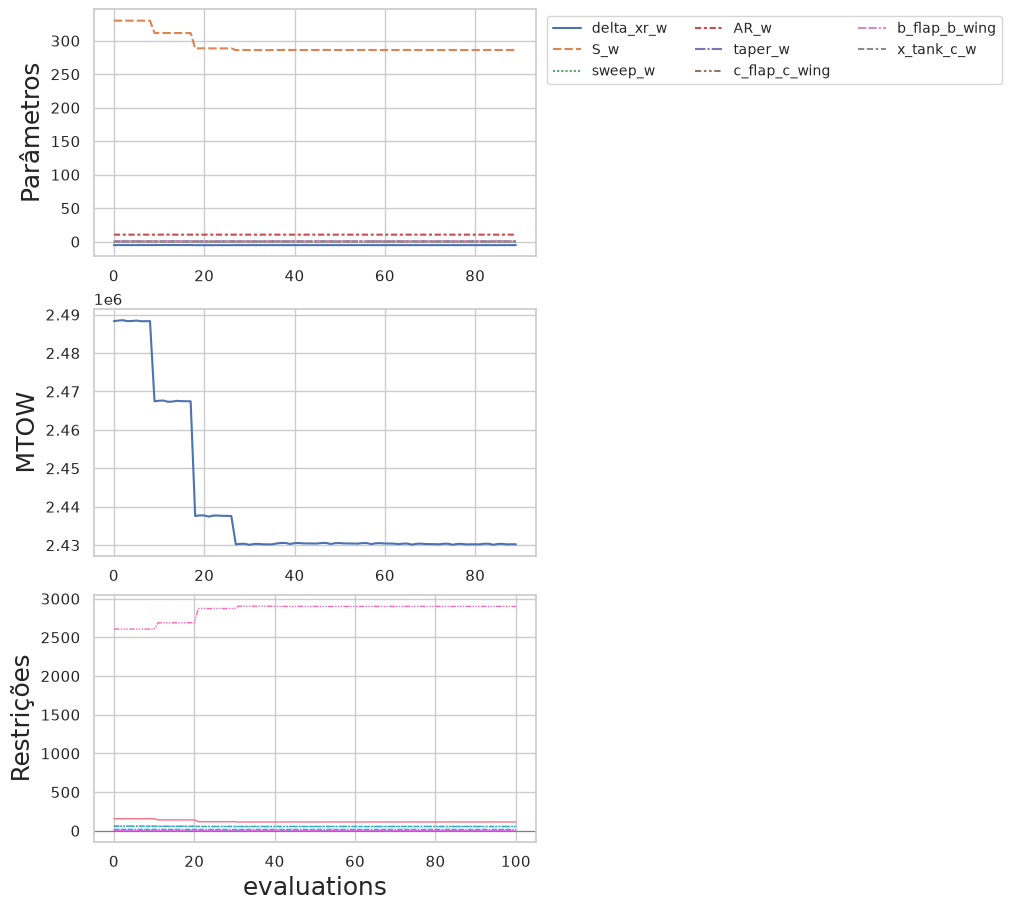

In [ ]:
parametros_data = pd.DataFrame(
    np.vstack(parametros_hist),
    columns=nomes_parametros
)

restricoes_data = pd.DataFrame(np.vstack(restricoes_hist))

plt.figure(figsize=(10, 9), constrained_layout=True)

# parametros_hist
plt.subplot(311)
sns.lineplot(data=parametros_data, linewidth=1.5)
plt.ylabel("Parâmetros", fontsize=18)
plt.xlabel("")
plt.legend()

# MTOW
plt.subplot(312)
sns.lineplot(
    x=np.arange(len(W0_hist)),
    y=np.asarray(W0_hist).squeeze(),
    linewidth=1.5
)
plt.ylabel("MTOW", fontsize=18)
plt.xlabel("")

# restricoes
plt.subplot(313)
sns.lineplot(
    data=restricoes_data,
    linewidth=1,
    legend=False
)
plt.axhline(0, color="gray", linewidth=0.8)
plt.ylabel("Restrições", fontsize=18)
plt.xlabel("evaluations", fontsize=18)

## 8. Is the optimum constrained? What are the active constraints?

Sim, ver onde Optimized Point coincide com Mínimo ou Máximo na tabela de restrições

# 4) Multiobjective Optimization
Minimizar W0(x) e Wf(x)

w.r.t. x = 6 variáveis

x0 = avião final PRJ-22

Restrições: iguais

Use MOGA algorithm from pymoo.

In [ ]:
airplane_name = "Tomav"
# IMPORTS
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.core.problem import ElementwiseProblem
import numpy as np
import matplotlib.pyplot as plt
# EXECUTION
# Define optimization problem
class ProblemaW0WfTomav(ElementwiseProblem):
    def __init__(self):
        # Set general characteristics of the problem
        super().__init__(n_var=6, # Number of design variables
                         n_obj=2, # Number of objective functions
                         n_ieq_constr=2, # Number of inequality constraints
                         xl=np.array([-2.0, -2.0]), # Lower bounds of design variables
                         xu=np.array([2.0, 2.0])) # Upper bound of design variables
    def _evaluate(self, X, out, *args, **kwargs):
        # # Split design variables
        # x1 = X[0]
        # x2 = X[1]
        # # Compute objectives
        # f1 = x1**2 + x2**2
        # f2 = (x1-1)**2 + x2**2
        # # Compute constraints
        # g1 = 2*(x1-0.1) * (x1-0.9) / 0.18
        # g2 = - 20*(x1-0.4) * (x1-0.6) / 4.8
        # # Gather results
        # out["F"] = np.array([f1, f2])
        # out["G"] = np.array([g1, g2])
        dados = calcular_dados_otimizacao(airplane_name, X, np.array([-2.0, -2.0]), np.array([2.0, 2.0]), nomes_parametros)
# Create an instance of the Problem
problem = ProblemaW0WfTomav()
# Select optimization algorithm
algorithm = NSGA2(pop_size=100, eliminate_duplicates=True)
# Solve the optimization
res = minimize(problem,
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=True)
# Plot the Pareto in the objective space
fig = plt.figure()
plt.plot(res.F[:,0], res.F[:,1], 'o')
plt.title('Objective Space',fontsize=20)
plt.xlabel(r'$f_1$',fontsize=20)
plt.ylabel(r'$f_2$',fontsize=20)
plt.tight_layout()
# Plot the Pareto in the design space
fig = plt.figure()
plt.plot(res.X[:,0], res.X[:,1], 'o')
plt.title('Design Space',fontsize=20)
plt.xlabel(r'$x_1$',fontsize=20)
plt.ylabel(r'$x_2$',fontsize=20)
plt.axis('equal')
plt.tight_layout()
#fig.savefig('pareto_nsga.pdf')


## 1. Plot the Pareto Front.

## 2. Show the number of generations and individuals per generation.

## 3. How would you use the results from Sec. 3 to verify the convergence of this multiobjective optimization?

## 4. Choose at least three aircraft from distinct regions of the Pareto Front. Draw their planforms and discuss how their differences impact the objective function values.

In [ ]:
# Mostrar figuras
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Lab2/fokker100_inicial.json'